<a href="https://colab.research.google.com/github/khansa-020/Deep-Fake-Detection/blob/main/DeepFake_InceptionV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


**Deep Learning with Transfer Learning & Explainibility**

# DeepFake Detection Dataset -InceptionV3
**Models:** Baseline CNN | InceptionV3 & DenseNet121 hybrid | **InceptionV3** | EfficientNetB3\
**Model:** InceptionV3 pre-trained on ImageNet\
**Framework:** PyTorch\
**Extras:** Grad-CAM Explainability on Best Model



---


# Section 1: Dataset Load & split

In [ ]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [ ]:
import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))

Train: ['Fake', 'Real']
Validation: ['Fake', 'Real']
Test: ['Fake', 'Real']
Real: 70001
Fake: 70001
Real: 5413
Fake: 5492
Real: 19787
Fake: 19641


In [ ]:
import os
import random
import shutil

base_path = "Dataset"

train_real = os.path.join(base_path, "Train/Real")
train_fake = os.path.join(base_path, "Train/Fake")

val_real = os.path.join(base_path, "Validation/Real")
val_fake = os.path.join(base_path, "Validation/Fake")


output_base = "Subset_Dataset"

os.makedirs(output_base, exist_ok=True)

for split in ["train", "test", "val"]:
    for cls in ["Real", "Fake"]:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

In [ ]:
real_images = os.listdir(train_real)
fake_images = os.listdir(train_fake)

real_sample = random.sample(real_images, 2500)
fake_sample = random.sample(fake_images, 2500)

for img in real_sample:
    shutil.copy(
        os.path.join(train_real, img),
        os.path.join(output_base, "train/Real", img)
    )

for img in fake_sample:
    shutil.copy(
        os.path.join(train_fake, img),
        os.path.join(output_base, "train/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/train/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/train/Fake")))
print("Train subset created ✔")

Real: 2500
Fake: 2500
Train subset created ✔


In [ ]:
val_real_imgs = os.listdir(val_real)
val_fake_imgs = os.listdir(val_fake)

val_real_sample = random.sample(val_real_imgs, 500)
val_fake_sample = random.sample(val_fake_imgs, 500)

for img in val_real_sample:
    shutil.copy(
        os.path.join(val_real, img),
        os.path.join(output_base, "val/Real", img)
    )

for img in val_fake_sample:
    shutil.copy(
        os.path.join(val_fake, img),
        os.path.join(output_base, "val/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/val/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/val/Fake")))
print("Validation subset created ✔")


Real: 500
Fake: 500
Validation subset created ✔


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

base = "Subset_Dataset"

# =========================
# PATHS
# =========================

train_real_path = os.path.join(base, "train/Real")
train_fake_path = os.path.join(base, "train/Fake")

# =========================
# CREATE OUTPUT FOLDERS
# =========================

os.makedirs(os.path.join(base, "final_train/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "final_train/Fake"), exist_ok=True)

os.makedirs(os.path.join(base, "test/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "test/Fake"), exist_ok=True)

# =========================
# LOAD IMAGE NAMES
# =========================

real_images = os.listdir(train_real_path)
fake_images = os.listdir(train_fake_path)

# =========================
# SPLIT REAL IMAGES
# =========================

train_real_imgs, test_real_imgs = train_test_split(
    real_images,
    test_size=0.2,
    random_state=42
)

# =========================
# SPLIT FAKE IMAGES
# =========================

train_fake_imgs, test_fake_imgs = train_test_split(
    fake_images,
    test_size=0.2,
    random_state=42
)

# =========================
# COPY TRAIN REAL
# =========================

for img in train_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "final_train/Real", img)
    )

# =========================
# COPY TRAIN FAKE
# =========================

for img in train_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "final_train/Fake", img)
    )

# =========================
# COPY TEST REAL
# =========================

for img in test_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "test/Real", img)
    )

# =========================
# COPY TEST FAKE
# =========================

for img in test_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "test/Fake", img)
    )

# =========================
# VERIFY COUNTS
# =========================

for split in ["final_train", "test", "val"]:
    print(f"\n{split.upper()}")

    for cls in ["Real", "Fake"]:
        path = os.path.join(base, split, cls)
        print(cls, ":", len(os.listdir(path)))


FINAL_TRAIN
Real : 2000
Fake : 2000

TEST
Real : 500
Fake : 500

VAL
Real : 500
Fake : 500


# Section 2: Imports & Dataset Preprocessing

In [ ]:
# ============================================================
# InceptionV3 DeepFake Detection
# Transfer Learning + ImageNet Pretrained
# Full Research Pipeline
# ============================================================

# ============================================================
# 1. INSTALLS
# ============================================================
!pip install torchsummary -q

# ============================================================
# 2. IMPORTS
# ============================================================
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torchvision import models

warnings.filterwarnings("ignore")

# ============================================================
# 3. SEED
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ============================================================
# 4. DEVICE
# ============================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)

DEVICE: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:
!rm -rf /content/drive

In [ ]:
!ls /content/drive/MyDrive/

'0-S&M Methods for DS Formula Sheet.gdoc'
 1-s2.0-S0957417425024613-main.gdoc
 Classroom
'Colab Notebooks'
'Comparitive Analysis of ML & DL on DeepFake'
'Copy of Final Project Github Repo.gsheet'
'CV kh FR.pdf'
'Khansa - dataset.gsheet'
'KHANSA IT.pdf'
 my.jpg
'Truck Assignment Automation'
 ViT_Medical_FineTuning
'What is Riba (Interest) in Islam, and Why is it Strictly Prohibited? A Critical and Analytical Study in the Light of Qur’an, Sunnah, and Contemporary Economic Systems.gdoc'
'Z-Table & T-Table.gdoc'


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/InceptionV3_DeepFake"

print("Exists:", os.path.exists(SAVE_DIR))

for root, dirs, files in os.walk(SAVE_DIR):
    print(f"\n{root}")
    for file in files:
        print(file)

Exists: True

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/InceptionV3_DeepFake


Total Parameters: 25,382,922
Trainable Parameters: 6,347,458

Epoch [1/10]


100%|██████████| 125/125 [04:11<00:00,  2.01s/it]


Epoch | TrainLoss 0.5422 | TrainAcc 0.7632 | ValLoss 0.4878 | ValAcc 0.7990 | TestLoss 0.4498 | TestAcc 0.8450 | LR 0.000098 | Best Model Saved

Epoch [2/10]


100%|██████████| 125/125 [04:02<00:00,  1.94s/it]


Epoch | TrainLoss 0.4446 | TrainAcc 0.8393 | ValLoss 0.4865 | ValAcc 0.8050 | TestLoss 0.4381 | TestAcc 0.8390 | LR 0.000090 | Best Model Saved

Epoch [3/10]


...

Epoch | TrainLoss 0.3591 | TrainAcc 0.9058 | ValLoss 0.4696 | ValAcc 0.8320 | TestLoss 0.4004 | TestAcc 0.8760 | LR 0.000002 | 

Epoch [10/10]


100%|██████████| 125/125 [03:48<00:00,  1.82s/it]


Epoch | TrainLoss 0.3521 | TrainAcc 0.9085 | ValLoss 0.4612 | ValAcc 0.8270 | TestLoss 0.4012 | TestAcc 0.8640 | LR 0.000000 | 

Training Time: 267.46 Minutes


100%|██████████| 125/125 [03:57<00:00,  1.90s/it]


              precision    recall  f1-score   support

        Fake     0.8713    0.8800    0.8756       500
        Real     0.8788    0.8700    0.8744       500

    accuracy                         0.8750      1000
   macro avg     0.8750    0.8750    0.8750      1000
weighted avg     0.8750    0.8750    0.8750      1000



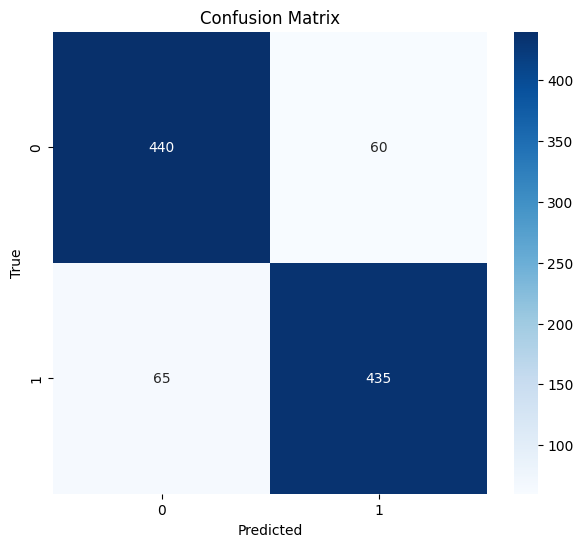

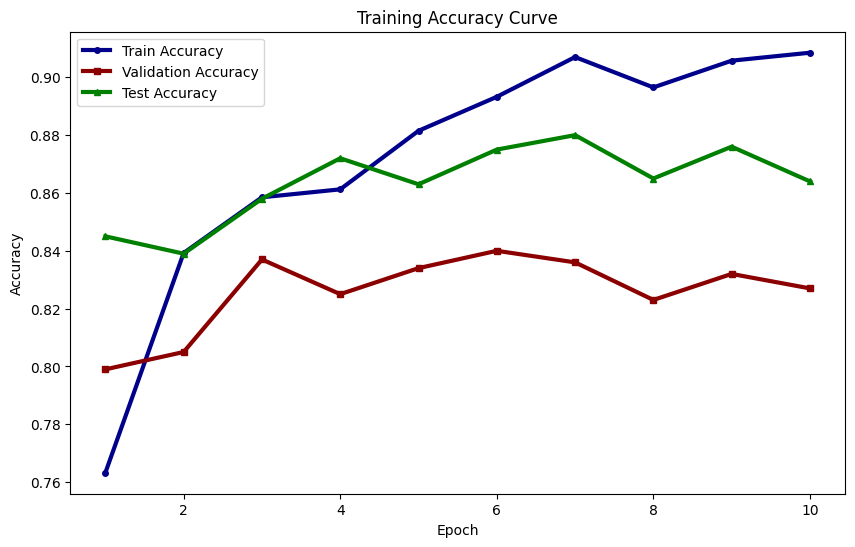

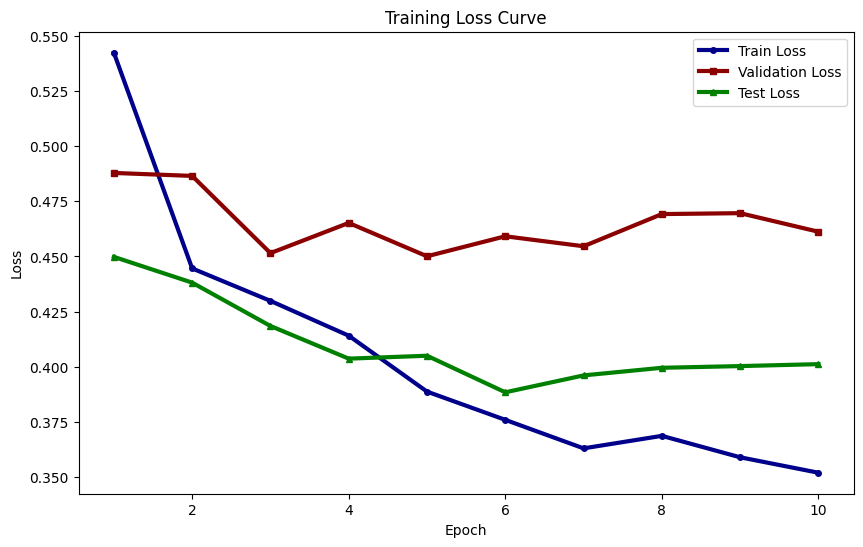


SET PERFORMANCE REPORT

Accuracy          : 87.50%
F1 (Macro)        : 0.8750
F1 (Weighted)     : 0.8750
Precision (W)     : 0.8750
Recall (W)        : 0.8750
ROC-AUC (macro)   : 0.9522
Test Loss         : 0.3885



ALL FILES SAVED SUCCESSFULLY
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/InceptionV3_DeepFake


In [ ]:
# ============================================================
# 5. SAVE DIRECTORIES
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/InceptionV3_DeepFake"

MODEL_DIR      = os.path.join(SAVE_DIR, "models")
CHECKPOINT_DIR = os.path.join(SAVE_DIR, "checkpoints")
LOG_DIR        = os.path.join(SAVE_DIR, "logs")
PLOT_DIR       = os.path.join(SAVE_DIR, "plots")
INFER_DIR      = os.path.join(SAVE_DIR, "inference")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)

# ============================================================
# 6. DATASET PATHS
# ============================================================
TRAIN_DIR = "/content/Subset_Dataset/final_train"
VAL_DIR   = "/content/Subset_Dataset/val"
TEST_DIR  = "/content/Subset_Dataset/test"

# ============================================================
# 7. HYPERPARAMETERS
# ============================================================
IMAGE_SIZE = 299
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 2
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1
MIXED_PRECISION = True
PATCH_SIZE = "3x3 Conv"
STRIDE = "1,2"
POOLING = "MaxPool + AvgPool"
ACTIVATION = "ReLU"
OPTIMIZER_NAME = "AdamW"
LOSS_NAME = "CrossEntropyLoss"

# ============================================================
# 8. PREPROCESSING (Paper Style)
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# 9. DATASETS
# ============================================================
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

# ============================================================
# 10. DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ============================================================
# 11. INCEPTIONV3 ARCHITECTURE
# ============================================================

"""
Input : 299 x 299 x 3
Conv 3x3 stride 2---149 x 149 x 32
Conv 3x3---147 x 147 x 32
Conv 3x3----147 x 147 x 64
MaxPool---73 x 73 x 64
Conv 1x1----73 x 73 x 80
Conv 3x3---71 x 71 x 192
MaxPool---35 x 35 x 192
Inception-A Blocks---35 x 35 x 256
Inception-A Blocks---35 x 35 x 288
Reduction-A---17 x 17 x 768
Inception-B Blocks---17 x 17 x 768
Reduction-B---8 x 8 x 1280
Inception-C Blocks---8 x 8 x 2048
Global Average Pooling---1 x 1 x 2048
FC Layer---2048 -> 128
FC Layer---128 -> 64
Output Layer---64 -> 2
"""

# ============================================================
# 12. MODEL
# ============================================================
class InceptionV3DeepFake(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.inception_v3(
    pretrained=True,
    aux_logits=True
)

        # Freeze lower layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze final blocks
        for param in self.backbone.Mixed_7c.parameters():
            param.requires_grad = True

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        outputs = self.backbone(x)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        return outputs

model = InceptionV3DeepFake().to(DEVICE)

# ============================================================
# 13. PARAMETER COUNT
# ============================================================
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# ============================================================
# 14. LOSS FUNCTION
# ============================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

# ============================================================
# 15. OPTIMIZER
# ============================================================
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ============================================================
# 16. SCHEDULER
# ============================================================
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ============================================================
# 17. MIXED PRECISION
# ============================================================
scaler = GradScaler(enabled=MIXED_PRECISION)

# ============================================================
# 18. TRAIN FUNCTION
# ============================================================
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    preds_all = []
    labels_all = []

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        with autocast(enabled=MIXED_PRECISION):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    return running_loss / len(loader), acc

# ============================================================
# 19. EVALUATION FUNCTION
# ============================================================
def evaluate(model, loader):
    model.eval()
    running_loss = 0
    preds_all = []
    labels_all = []
    logits_all = []
    probs_all = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            running_loss += loss.item()
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            logits_all.extend(outputs.cpu().numpy())
            probs_all.extend(probs[:,1].cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)

    return (
        running_loss / len(loader),
        acc,
        labels_all,
        preds_all,
        logits_all,
        probs_all
    )

# ============================================================
# 20. TRAINING LOOP
# ============================================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "test_loss": [],
    "test_acc": [],
    "lr": []
}

best_acc = 0
start_time = time.time()
for epoch in range(EPOCHS):

    print("\n" + "="*70)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("="*70)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, _, _, _, _ = evaluate(
        model,
        val_loader
    )

    test_loss, test_acc, _, _, _, _ = evaluate(
        model,
        test_loader
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["lr"].append(current_lr)
    note = ""

    # SAVE BEST MODEL
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_model.pth")
  )
        note = "Best Model Saved"

    # SAVE CHECKPOINT
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            f"checkpoint_epoch_{epoch+1}.pth")
    )

    print(
        f"Epoch | "
        f"TrainLoss {train_loss:.4f} | "
        f"TrainAcc {train_acc:.4f} | "
        f"ValLoss {val_loss:.4f} | "
        f"ValAcc {val_acc:.4f} | "
        f"TestLoss {test_loss:.4f} | "
        f"TestAcc {test_acc:.4f} | "
        f"LR {current_lr:.6f} | "
        f"{note}" )

# ============================================================
# 21. TRAINING TIME
# ============================================================
total_time = time.time() - start_time
print(f"\nTraining Time: {total_time/60:.2f} Minutes")

# ============================================================
# 22. SAVE TRAINING LOGS
# ============================================================
history_df = pd.DataFrame(history)
history_df.to_csv(
    os.path.join(LOG_DIR, "training_logs.csv"),
    index=False
)

# ============================================================
# 23. LOAD BEST MODEL
# ============================================================
model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR, "best_model.pth")
    )
)

# ============================================================
# 24. FINAL TEST
# ============================================================
test_loss, test_acc, y_true, y_pred, logits, probs = evaluate(
    model,
    test_loader
)

# ============================================================
# 25. SAVE LOGITS
# ============================================================
np.save(
    os.path.join(INFER_DIR, "logits.npy"),
    np.array(logits)
)

# ============================================================
# 26. CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    digits=4
)

print(report)
with open(
    os.path.join(LOG_DIR, "classification_report.txt"),"w") as f:
    f.write(report)

# ============================================================
# 27. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6), facecolor='white')
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches='tight',
    facecolor='white')
plt.show()

# ============================================================
# 28. ACCURACY CURVE
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10,6), facecolor='white')

plt.plot(
    epochs_range,
    history["train_acc"],
    color='darkblue',
    marker='o',
    markersize=4,
    linewidth=3,
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    history["val_acc"],
    color='darkred',
    marker='s',
    markersize=4,
    linewidth=3,
    label='Validation Accuracy'
)

plt.plot(
    epochs_range,
    history["test_acc"],
    color='green',
    marker='^',
    markersize=4,
    linewidth=3,
    label='Test Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()
plt.grid(False)
plt.savefig(
    os.path.join(PLOT_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

# ============================================================
# 29. LOSS CURVE
# ============================================================
plt.figure(figsize=(10,6), facecolor='white')

plt.plot(
    epochs_range,
    history["train_loss"],
    color='darkblue',
    marker='o',
    markersize=4,
    linewidth=3,
    label='Train Loss'
)

plt.plot(
    epochs_range,
    history["val_loss"],
    color='darkred',
    marker='s',
    markersize=4,
    linewidth=3,
    label='Validation Loss'
)

plt.plot(
    epochs_range,
    history["test_loss"],
    color='green',
    marker='^',
    markersize=4,
    linewidth=3,
    label='Test Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(False)
plt.savefig(
    os.path.join(PLOT_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

# ============================================================
# 30. PERFORMANCE REPORT
# ============================================================
accuracy = accuracy_score(y_true, y_pred)

f1_macro = f1_score(
    y_true,
    y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

roc_auc = roc_auc_score(y_true, probs)

performance = f"""
==================================================
SET PERFORMANCE REPORT
==================================================

Accuracy          : {accuracy*100:.2f}%
F1 (Macro)        : {f1_macro:.4f}
F1 (Weighted)     : {f1_weighted:.4f}
Precision (W)     : {precision_weighted:.4f}
Recall (W)        : {recall_weighted:.4f}
ROC-AUC (macro)   : {roc_auc:.4f}
Test Loss         : {test_loss:.4f}

==================================================
"""

print(performance)
with open(
    os.path.join(LOG_DIR, "performance_report.txt"),
    "w"
) as f:
     f.write(performance)

# ============================================================
# 31. SAVE HYPERPARAMETERS
# ============================================================
hyperparameters = {

    "Model": "InceptionV3",
    "Pretrained": "ImageNet",
    "Input Size": IMAGE_SIZE,
    "Patch Size": PATCH_SIZE,
    "Stride": STRIDE,
    "Pooling": POOLING,
    "Filters": "32,64,80,192,256,768,1280,2048",
    "Conv Layers": "Inception Blocks",
    "Fully Connected": "2048->128->64->2",
    "Activation": ACTIVATION,
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning Rate": LR,
    "Optimizer": OPTIMIZER_NAME,
    "Loss Function": LOSS_NAME,
    "Dropout": DROPOUT,
    "Weight Decay": WEIGHT_DECAY,
    "Label Smoothing": LABEL_SMOOTHING,
    "Mixed Precision FP16": MIXED_PRECISION,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params}

with open(
    os.path.join(LOG_DIR, "hyperparameters.json"),
    "w"
) as f:

    json.dump(hyperparameters, f, indent=4)

print("\nALL FILES SAVED SUCCESSFULLY")
print(SAVE_DIR)

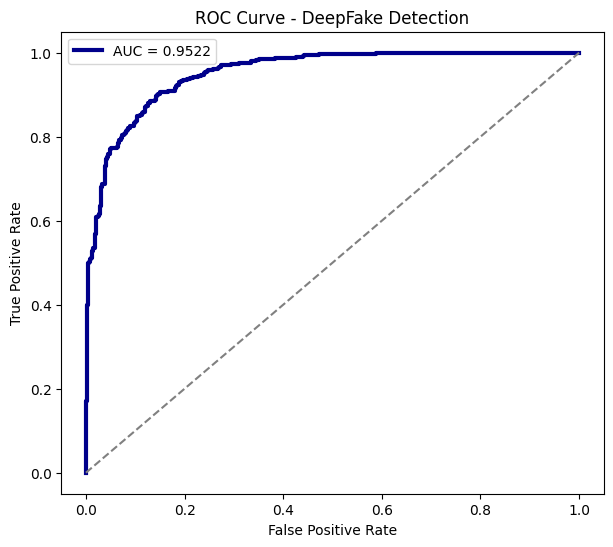

Top-1 AUC: 0.9522240000000001


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# y_true: ground truth labels (0/1)
# probs: predicted probability for class "fake"

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

top1_auc = roc_auc_score(y_true, probs)

plt.figure(figsize=(7,6), facecolor="white")

plt.plot(fpr, tpr, color="darkblue", linewidth=3, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"--",color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DeepFake Detection")
plt.legend()
plt.grid(False)

plt.savefig(os.path.join(PLOT_DIR, "roc_auc.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Top-1 AUC:", top1_auc)

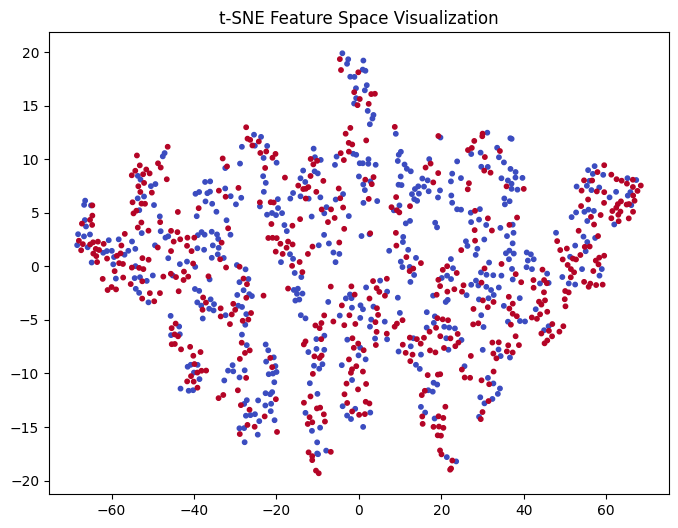

In [ ]:
from sklearn.manifold import TSNE
import torch

model.eval()

features = []
labels_list = []

def extract_features(loader):
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)

            # remove classification head
            # feat = model.backbone.Mixed_7c(x)  # Inception feature layer
            feat = model.backbone.avgpool(x)
            feat = torch.flatten(feat, 1)
            # feat = torch.mean(feat, dim=[2,3])  # GAP

            features.append(feat.cpu().numpy())
            labels_list.extend(y.numpy())

extract_features(test_loader)

features = np.concatenate(features, axis=0)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

plt.figure(figsize=(8,6), facecolor="white")

plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=labels_list,
    cmap="coolwarm",
    s=10
)

plt.title("t-SNE Feature Space Visualization")

plt.savefig(os.path.join(PLOT_DIR, "tsne.png"), dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import cv2
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, x, class_idx):
        output = self.model(x)

        self.model.zero_grad()
        loss = output[:, class_idx]
        loss.backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)

        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (224,224))

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

['Fake', 'Real']


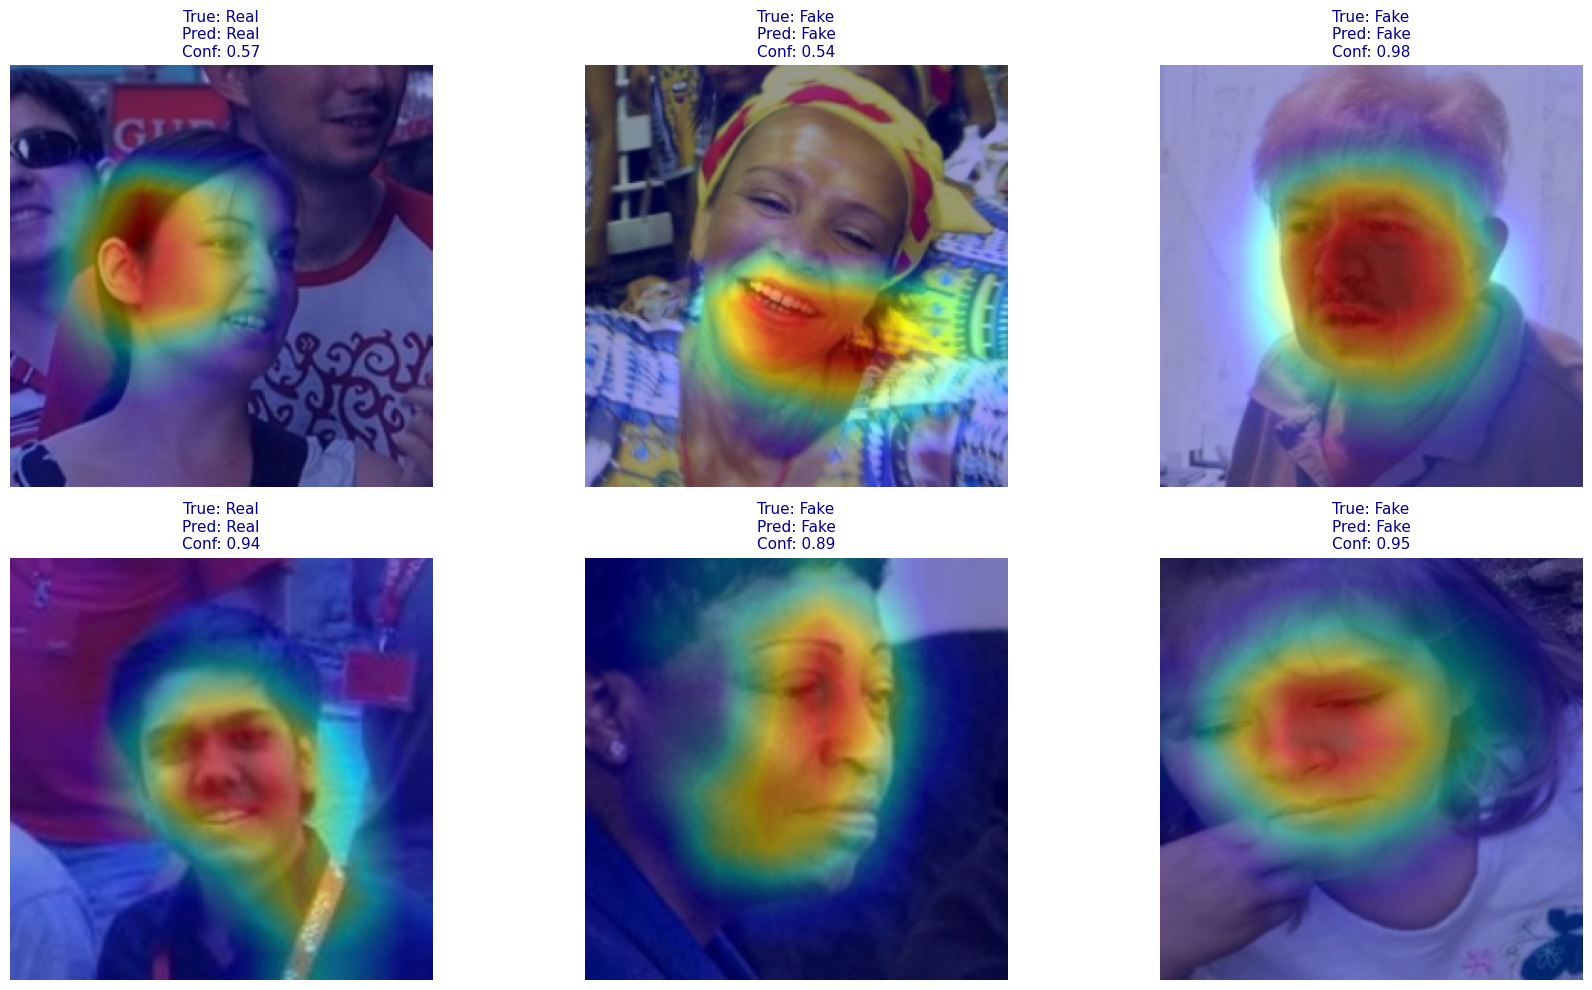


Grad-CAM samples saved in:
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/InceptionV3_DeepFake/plots/gradcam_samples


In [ ]:
# ============================================================
# GRAD-CAM FROM TEST SAMPLER
# Random Sample Visualization
# ============================================================

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image

# ============================================================
# CREATE SAVE DIRECTORY
# ============================================================
GRADCAM_DIR = os.path.join(PLOT_DIR, "gradcam_samples")

os.makedirs(GRADCAM_DIR, exist_ok=True)

# ============================================================
# GRAD-CAM CLASS
# ============================================================
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model

        self.target_layer = target_layer

        self.gradients = None

        self.activations = None

        target_layer.register_forward_hook(
            self.forward_hook
        )

        target_layer.register_full_backward_hook(
            self.backward_hook
        )

    def forward_hook(self, module, input, output):

        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):

        self.gradients = grad_output[0]

    def generate(self, x, class_idx):

        self.model.zero_grad()

        output = self.model(x)

        score = output[:, class_idx]

        score.backward()

        gradients = self.gradients

        activations = self.activations

        weights = gradients.mean(
            dim=(2,3),
            keepdim=True
        )

        cam = (weights * activations).sum(dim=1)

        cam = F.relu(cam)

        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (224,224))

        cam = (cam - cam.min()) / (
            cam.max() - cam.min() + 1e-8
        )

        return cam

# ============================================================
# INITIALIZE GRADCAM
# ============================================================
gradcam = GradCAM(
    model,
    model.backbone.Mixed_7c
)

# ============================================================
# CLASS NAMES
# ============================================================
class_names = test_dataset.classes

print(class_names)

# ============================================================
# RANDOM SAMPLE SELECTION
# ============================================================
NUM_SAMPLES = 6

random_indices = random.sample(
    range(len(test_dataset)),
    NUM_SAMPLES
)

# ============================================================
# VISUALIZATION
# ============================================================
plt.figure(
    figsize=(18,10),
    facecolor="white"
)

for idx, sample_idx in enumerate(random_indices):

    # ========================================================
    # LOAD SAMPLE
    # ========================================================
    image_tensor, label = test_dataset[sample_idx]

    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    # ========================================================
    # MODEL PREDICTION
    # ========================================================
    model.eval()

    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(outputs, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs[0][pred].item()

    # ========================================================
    # GENERATE CAM
    # ========================================================
    cam = gradcam.generate(
        input_tensor,
        class_idx=pred
    )

    # ========================================================
    # ORIGINAL IMAGE
    # ========================================================
    image_np = image_tensor.permute(1,2,0).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])

    std = np.array([0.229, 0.224, 0.225])

    image_np = std * image_np + mean

    image_np = np.clip(image_np, 0, 1)

    image_np = np.uint8(image_np * 255)

    image_np = cv2.resize(image_np, (224,224))

    # ========================================================
    # HEATMAP
    # ========================================================
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    # ========================================================
    # OVERLAY
    # ========================================================
    overlay = cv2.addWeighted(
        image_np,
        0.6,
        heatmap,
        0.4,
        0
    )

    # ========================================================
    # PLOT
    # ========================================================
    plt.subplot(2, 3, idx+1)

    plt.imshow(overlay)

    true_label = class_names[label]

    pred_label = class_names[pred]

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Conf: {confidence:.2f}",
        fontsize=11,
        color="darkblue"
    )

    plt.axis("off")

    # ========================================================
    # SAVE INDIVIDUAL IMAGE
    # ========================================================
    save_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_sample_{idx+1}.png"
    )

    cv2.imwrite(
        save_path,
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )

# ============================================================
# SAVE GRID
# ============================================================
plt.tight_layout()

grid_path = os.path.join(
    GRADCAM_DIR,
    "gradcam_grid.png"
)

plt.savefig(
    grid_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\nGrad-CAM samples saved in:")
print(GRADCAM_DIR)